In [1]:
import os
import sys
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf

2025-12-14 20:09:23.035825: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-14 20:09:28.894014: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 20:09:42.153729: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

from src.config import *

# Tắt các cảnh báo của TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow Version: {tf.__version__}")
print(f"Librosa Version: {librosa.__version__}")

TensorFlow Version: 2.20.0
Librosa Version: 0.11.0


In [3]:
model_path = os.path.join('..', 'models', 'best_model.h5')

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully!")
    model.summary()
else:
    print("Model file not found. Please train the model first.")

2025-12-14 20:11:30.944074: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 130, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 130, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 65, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 65, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 65, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 33, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 33, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 33, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 17, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       540,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 639,308 (2.44 MB)

 Trainable params: 638,858 (2.44 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

In [4]:
def process_input_file(file_path):
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True) # Load file với SR chuẩn, ép về Mono
    signal, _ = librosa.effects.trim(signal) # Cắt bỏ khoảng lặng (Silence) ở đầu và cuối bài hát
    signal = librosa.util.normalize(signal)

    if len(signal) > SAMPLE_RATE * 60:
        signal = signal[int(SAMPLE_RATE*15):]
    
    # Tính số lượng đoạn 3s có thể cắt được
    samples_per_track = SAMPLES_PER_TRACK
    num_segments = int(len(signal) / samples_per_track)  
    batch_data = []
    
    for d in range(num_segments):
        start = int(samples_per_track * d)
        finish = start + int(samples_per_track)
        segment = signal[start:finish]
        
        # Tạo Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=segment, 
            sr=sr, 
            n_mels=N_MELS, 
            n_fft=N_FFT, 
            hop_length=HOP_LENGTH
        )
        log_mel_spec = librosa.power_to_db(mel_spec)
        
        # Transpose (Time, Mel)
        log_mel_spec = log_mel_spec.T
        
        # Thêm vào batch
        batch_data.append(log_mel_spec)
        
    # Chuyển sang numpy array và thêm chiều channel (Batch, Time, Mel, 1)
    X_batch = np.array(batch_data)
    X_batch = X_batch[..., np.newaxis]
    
    return X_batch, signal, sr

In [5]:
# GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
from src.config import GENRES, SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, SAMPLES_PER_TRACK

def predict_and_plot(file_path):
    # 1. Xử lý dữ liệu
    X_batch, signal, sr = process_input_file(file_path)
    
    # 2. Dự đoán trên tất cả các đoạn (Batch prediction)
    # Kết quả trả về là (Num_segments, 10) - xác suất của mỗi đoạn cho 10 loại
    predictions = model.predict(X_batch) 

    # Chỉ lấy những đoạn mà xác suất cao nhất > 0.7 (Model khá chắc chắn)
    # Nếu không có đoạn nào > 0.7 thì chấp nhận lấy tất cả
    high_confidence_indices = np.max(predictions, axis=1) > 0.7
    
    if np.sum(high_confidence_indices) > 0:
        filtered_predictions = predictions[high_confidence_indices]
        # print(f"Đã lọc bỏ nhiễu: Chỉ dùng {len(filtered_predictions)}/{len(predictions)} đoạn tin cậy cao để tính toán.")
        avg_prediction = np.mean(filtered_predictions, axis=0)
    else:
        # print("⚠️ Cảnh báo: Bài hát này khó phân loại (Confidence thấp), dùng toàn bộ bài.")
        avg_prediction = np.mean(predictions, axis=0)
    
    # 3. Tính trung bình cộng xác suất của tất cả các đoạn (Majority Voting/Average)
    avg_prediction = np.mean(predictions, axis=0)
    
    # Lấy nhãn có xác suất cao nhất
    predicted_index = np.argmax(avg_prediction)
    predicted_genre = GENRES[predicted_index]
    confidence = avg_prediction[predicted_index]
    
    print(f"File: {os.path.basename(file_path)}")
    print(f"Predicted Genre: 👉 {predicted_genre.upper()} ({confidence*100:.2f}%)")
    
    # --- VISUALIZATION ---
    plt.figure(figsize=(14, 8))
    
    # Biểu đồ 1: Mel Spectrogram của đoạn đầu tiên (Minh họa)
    plt.subplot(2, 2, 1)
    # Lấy đoạn đầu tiên để vẽ, bỏ chiều channel
    spec_to_plot = X_batch[0].squeeze().T 
    librosa.display.specshow(spec_to_plot, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram (First 3s segment)')
    
    # Biểu đồ 2: Waveform
    plt.subplot(2, 2, 2)
    librosa.display.waveshow(signal, sr=sr, alpha=0.6)
    plt.title('Waveform')
    
    # Biểu đồ 3: Prediction Probabilities (Bar Chart)
    plt.subplot(2, 1, 2)
    colors = ['gray'] * len(GENRES)
    colors[predicted_index] = 'red' # Tô đỏ cột dự đoán đúng
    
    plt.bar(GENRES, avg_prediction, color=colors)
    plt.ylabel('Probability')
    plt.title('Model Confidence per Genre')
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
File: hiphop.00010.wav
Predicted Genre: 👉 HIPHOP (99.46%)


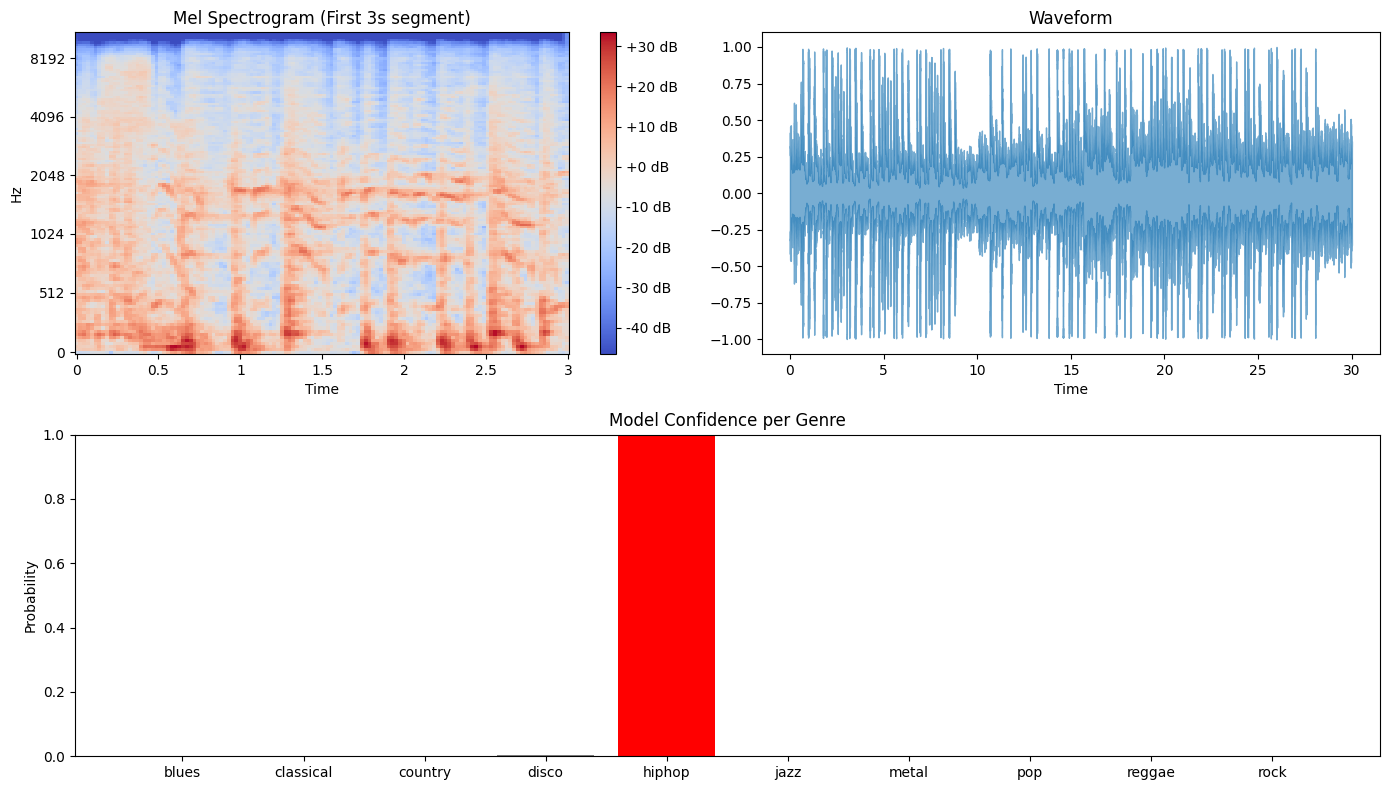

In [8]:
# Chọn một file nhạc để test
# Ví dụ: lấy file từ tập dataset gốc
test_file = os.path.join('..', 'data', 'genres_original', 'hiphop', 'hiphop.00010.wav')

# Hoặc file nhạc bên ngoài (uncomment dòng dưới)
# test_file = "/home/kotonedayo/Music/test/old/Paul _Wine_ Jones - Pucker Up, Butter Cup.mp3" 

if os.path.exists(test_file):
    predict_and_plot(test_file)
else:
    print("File not found! Check the path.")

In [14]:
from tkinter import filedialog
import tkinter as tk
import os

def select_file_and_predict():
    print("Opening")
    
    # 1. Khởi tạo Tkinter (ẩn cửa sổ chính)
    root = tk.Tk()
    root.withdraw() # Ẩn cửa sổ gốc nhỏ xíu của Tkinter
    
    # Đẩy cửa sổ chọn file lên trên cùng (Topmost) để không bị che
    root.call('wm', 'attributes', '.', '-topmost', True)
    
    # 2. Mở File Dialog
    file_path = filedialog.askopenfilename(
        title="Chọn file nhạc để phân loại",
        filetypes=[
            ("Audio Files", "*.wav *.mp3 *.au *.flac"),
            ("All Files", "*.*")
        ]
    )
    
    # 3. Kiểm tra và Dự đoán
    if file_path:
        print(f"ã chọn file: {file_path}")
        # Gọi hàm dự đoán đã định nghĩa ở Cell 4
        predict_and_plot(file_path)
    else:
        print("Bạn chưa chọn file nào (Đã hủy thao tác).")

# Chạy hàm
if __name__ == "__main__":
    select_file_and_predict()

ModuleNotFoundError: No module named 'tkinter'